In [22]:
!git config --global user.email "silasschack@hotmail.com"
!git config --global user.name "SilasSchack"

In [23]:
pip install pymatgen

In [24]:
pip install matgl

In [38]:
path = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D/data/final/MP"
path_red = r"C:/Users/rasmu/OneDrive/Skrivebord/1-NytdropPython/4.year/AppliedML2026/Examproject/3DSC/superconductors_3D"
path = r"/content/ML_Personal_git"
path_red = r"/content/ML_Personal_git"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pymatgen.core import Structure
import matgl
from matgl.ext.pymatgen import Structure2Graph

import networkx as nx
import matplotlib.pyplot as plt
from pymatgen.core import Element

import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

In [26]:
  !git clone https://github.com/SSBNS/ML_Personal_git.git

fatal: destination path 'ML_Personal_git' already exists and is not an empty directory.


In [27]:
data_only_id = pd.read_csv("/content/ML_Personal_git/3DSC_ICSD_only_IDs.csv", skiprows=1)
data = pd.read_csv("/content/ML_Personal_git/3DSC_ICSD.csv", skiprows=1)
cif_ex = pd.read_csv("/content/ML_Personal_git/ex_cifs.csv", skiprows=0)
#print(data.columns)
print(data.loc[0,'tc'])

1.128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/cifs.zip", 'r') as z:
    z.extractall("/content/cifs")

Mounted at /content/drive


In [ ]:
from pymatgen.core import Composition
max_Z = max(el.Z for formula in data["formula_sc"] for el in Composition(formula).elements)
print(max_Z)

94


In [ ]:
structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
structure

In [ ]:
tc_list = []
for i in range(len(data)):
    # if data.loc[i,'tc'] > 0:
    tc_list.append(data.loc[i,'tc'])
tc_list = np.array(tc_list)
print(np.mean(np.log(tc_list)))
print(np.std(np.log(tc_list)))

In [ ]:
print(np.sum(tc_list == 0))
plt.hist((np.log(tc_list)-1.7)/1.5, bins=100)
plt.show()

In [28]:
import numpy as np
from pymatgen.analysis.local_env import VoronoiNN, LocalStructOrderParams
from pymatgen.analysis.bond_valence import BVAnalyzer

MAX_Z = 94
ALL_ELEMENTS = list(range(1, MAX_Z+1))  # Z = 1 to 94, adjust to your dataset

def one_hot_element(elem, all_z=ALL_ELEMENTS):
    z = int(elem.Z)
    return [1.0 if z == z_i else 0.0 for z_i in all_z]

# ─── Oxidation-state decoration (best-effort) ────────────────────────────────

def try_decorate_oxidation(structure):
    """Try to assign oxidation states via bond-valence analysis.
    Returns the decorated structure, or the original if it fails."""
    try:
        bv = BVAnalyzer()
        return bv.get_oxi_state_decorated_structure(structure)
    except Exception:
        return structure


# ─── Local environment analysis (best-effort) ────────────────────────────────

def compute_local_env(structure):
    """
    Returns per-site dicts with:
      - coordination_number  (float)
      - order_params         (list of 5 floats: cn, tet, oct, sq, bent)
      - voronoi_volume       (float)
      - mean_solid_angle     (float)
      - std_solid_angle      (float)
      - mean_face_area       (float)
    Falls back to zeros on failure.
    """
    n = len(structure)
    zero_env = {
        "coordination_number": 0.0,
        "order_params":        [0.0] * 5,
        "voronoi_volume":      0.0,
        "mean_solid_angle":    0.0,
        "std_solid_angle":     0.0,
        "mean_face_area":      0.0,
    }

    try:
        vnn   = VoronoiNN(compute_adj_neighbors=False)
        lsop  = LocalStructOrderParams(["cn", "tet", "oct", "sq", "bent"])
        results = []

        for i in range(n):
            try:
                poly  = vnn.get_voronoi_polyhedra(structure, i)  # {site: stats_dict}
                stats = list(poly.values())

                cn           = float(len(stats))
                solid_angles = np.array([s["solid_angle"] for s in stats])
                face_areas   = np.array([s["area"]        for s in stats])
                volume       = float(sum(s["volume"] for s in stats))

                op = lsop.get_order_parameters(structure, i)
                op = [v if v is not None else 0.0 for v in op]

                results.append({
                    "coordination_number": cn,
                    "order_params":        op,
                    "voronoi_volume":      volume,
                    "mean_solid_angle":    float(solid_angles.mean()),
                    "std_solid_angle":     float(solid_angles.std()),
                    "mean_face_area":      float(face_areas.mean()),
                })
            except Exception:
                results.append(zero_env.copy())

        return results

    except Exception:
        return [zero_env.copy() for _ in range(n)]


# ─── Per-element scalar features ─────────────────────────────────────────────

def _elem_features_Z(elem):
    """Extract scalar features from a pymatgen Element/Species object.
    All values are cast to float; missing values become 0.0."""
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state (present only on Species, not bare Element)
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range (proxy for chemical versatility)
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    return [
        # Identity
        safe(elem.Z),                       # atomic number
        safe(elem.atomic_mass),             # atomic mass  (u)
        # Size
        safe(elem.atomic_radius),           # atomic radius (Å)
        safe(elem.average_ionic_radius),    # avg ionic radius (Å)
        # Chemistry
        safe(elem.X),                       # Pauling electronegativity
        safe(elem.max_oxidation_state),     # max ox. state
        safe(elem.min_oxidation_state),     # min ox. state
        ox,                                 # assigned ox. state (0 if unknown)
        ox_range,                           # ox. state range

    ]

# Total length of _elem_features output — update if you add/remove entries
N_ELEM_FEATURES = 9

def _elem_features(elem):
    """Extract scalar features from a pymatgen Element/Species object.
    All values are cast to float; missing values become 0.0."""
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state (present only on Species, not bare Element)
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range (proxy for chemical versatility)
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    return [
        # Identity
        # safe(elem.Z),                       # atomic number
        *one_hot_element(elem),     # e.g. 94 binary features for element identity
        safe(elem.atomic_mass),             # atomic mass  (u)
        # Size
        safe(elem.atomic_radius),           # atomic radius (Å)
        safe(elem.average_ionic_radius),    # avg ionic radius (Å)
        # Chemistry
        safe(elem.X),                       # Pauling electronegativity
        safe(elem.max_oxidation_state),     # max ox. state
        safe(elem.min_oxidation_state),     # min ox. state
        ox,                                 # assigned ox. state (0 if unknown)
        ox_range,                           # ox. state range

    ]

def _elem_features(elem):
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    # Valence electron count
    try:
        valence_electrons = float(sum(elem.valence))
    except Exception:
        valence_electrons = 0.0

    # d-electron count (from electronic structure string e.g. '[Ar] 3d5 4s1')
    try:
        d_electrons = float(elem.full_electronic_structure[-1][2]
                           if elem.full_electronic_structure[-1][1] == 'd'
                           else next((n for _, shell, n in elem.full_electronic_structure
                                     if shell == 'd'), 0))
    except Exception:
        d_electrons = 0.0

    # Block flags
    try:
        is_d_block = 1.0 if elem.block == 'd' else 0.0
        is_f_block = 1.0 if elem.block == 'f' else 0.0
    except Exception:
        is_d_block, is_f_block = 0.0, 0.0

    # Molar volume
    try:
        molar_volume = safe(elem.molar_volume)
    except Exception:
        molar_volume = 0.0

    # Mendeleev number
    try:
        mendeleev_no = safe(elem.mendeleev_no)
    except Exception:
        mendeleev_no = 0.0

    return [
        # Identity
        *one_hot_element(elem),         # 94 one-hot
        safe(elem.atomic_mass),         # atomic mass (u)
        # Size
        safe(elem.atomic_radius),       # atomic radius (Å)
        safe(elem.average_ionic_radius),# avg ionic radius (Å)
        molar_volume,                   # molar volume
        # Chemistry
        safe(elem.X),                   # Pauling electronegativity
        safe(elem.max_oxidation_state), # max ox. state
        safe(elem.min_oxidation_state), # min ox. state
        ox,                             # assigned ox. state
        ox_range,                       # ox. state range
        valence_electrons,              # total valence electrons
        d_electrons,                    # d-electron count
        is_d_block,                     # d-block flag
        is_f_block,                     # f-block flag
        mendeleev_no,                   # Mendeleev number
    ]

# Total: 94 (one-hot) + 14 (scalar) = 108 elemental features
N_ELEM_FEATURES = MAX_Z + 14

# N_ELEM_FEATURES = MAX_Z + 8


# ─── Main feature builder ─────────────────────────────────────────────────────

def get_atom_features_hot_env(structure):
    """
    Build a node feature matrix for `structure`.

    Feature layout (per node):
│ Elemental features (one-hot + scalar) │ 108    │
│ Occupancy                             │   1    │
│ Site disorder                         │   1    │
│ Fractional coordinates                │   3    │
│ Coordination number                   │   1    │
│ Order params                          │   5    │
│ Voronoi volume + angles + area        │   4    │
├───────────────────────────────────────┼────────┤
│ Total                                 │ 123    │

    Returns
    -------
    np.ndarray of shape (n_sites, 33), dtype float32
    """
    # Best-effort oxidation-state decoration
    structure = try_decorate_oxidation(structure)

    # Pre-compute local environment for all sites
    local_env = compute_local_env(structure)

    features = []

    for i, site in enumerate(structure):
        env = local_env[i]

        # ── Structural / site descriptors (same for ordered & disordered) ──
        frac    = list(site.frac_coords)                          # (3,)
        cn      = [env["coordination_number"]]                    # (1,)
        op      = env["order_params"]                             # (5,)
        voro    = [
            env["voronoi_volume"],
            env["mean_solid_angle"],
            env["std_solid_angle"],
            env["mean_face_area"],
        ]                                                         # (4,)

        # ── Elemental descriptors ──────────────────────────────────────────
        if site.is_ordered:
            elem      = site.specie
            elem_feat = _elem_features(elem)
            occupancy = 1.0
            disorder  = 0.0

        else:
            # Weighted average of elemental features over species
            occupancies = list(site.species.values())
            disorder    = -sum(o * np.log(o + 1e-9) for o in occupancies)
            occupancy   = max(occupancies)

            elem_feat   = np.zeros(N_ELEM_FEATURES, dtype=np.float64)
            for elem, occ in site.species.items():
                elem_feat += occ * np.array(_elem_features(elem), dtype=np.float64)
            elem_feat = elem_feat.tolist()

        # ── Concatenate all blocks ─────────────────────────────────────────
        node = [
            *elem_feat,       # 18
            occupancy,        #  1
            disorder,         #  1
            *frac,            #  3
            *cn,              #  1
            *op,              #  5
            *voro,            #  4
        ]                     # = 33 total

        features.append(node)

    return np.array(features, dtype=np.float32)

In [29]:
def get_atom_features_hot_noenv(structure):
    """
    Build a node feature matrix for `structure`.

    Feature layout (per node):
│ Elemental features (one-hot + scalar) │ 108    │
│ Occupancy                             │   1    │
│ Site disorder                         │   1    │
│ Fractional coordinates                │   3    │
│ Coordination number                   │   1    │
│ Order params                          │   5    │
│ Voronoi volume + angles + area        │   4    │
├───────────────────────────────────────┼────────┤
│ Total                                 │ 123    │

    Returns
    -------
    np.ndarray of shape (n_sites, 33), dtype float32
    """
    # Best-effort oxidation-state decoration
    structure = try_decorate_oxidation(structure)

    # Pre-compute local environment for all sites
    # local_env = compute_local_env(structure)

    features = []

    for i, site in enumerate(structure):
        # env = local_env[i]

        # ── Structural / site descriptors (same for ordered & disordered) ──
        frac    = list(site.frac_coords)                          # (3,)
        # cn      = [env["coordination_number"]]                    # (1,)
        # op      = env["order_params"]                             # (5,)
        # voro    = [
        #     env["voronoi_volume"],
        #     env["mean_solid_angle"],
        #     env["std_solid_angle"],
        #     env["mean_face_area"],
        # ]                                                         # (4,)

        # ── Elemental descriptors ──────────────────────────────────────────
        if site.is_ordered:
            elem      = site.specie
            elem_feat = _elem_features(elem)
            occupancy = 1.0
            disorder  = 0.0

        else:
            # Weighted average of elemental features over species
            occupancies = list(site.species.values())
            disorder    = -sum(o * np.log(o + 1e-9) for o in occupancies)
            occupancy   = max(occupancies)

            elem_feat   = np.zeros(N_ELEM_FEATURES, dtype=np.float64)
            for elem, occ in site.species.items():
                elem_feat += occ * np.array(_elem_features(elem), dtype=np.float64)
            elem_feat = elem_feat.tolist()

        # ── Concatenate all blocks ─────────────────────────────────────────
        node = [
            *elem_feat,       # 18
            occupancy,        #  1
            disorder,         #  1
            *frac,            #  3
            # *cn,              #  1
            # *op,              #  5
            # *voro,            #  4
        ]                     # = 33 total

        features.append(node)

    return np.array(features, dtype=np.float32)

In [30]:
# Gaussian basis expansion for bond distances (like CGCNN)
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

# def get_atom_features(structure):
#     features = []
#     for site in structure:

#         if site.is_ordered:
#             elem = site.specie
#             features.append([
#                 float(elem.Z),
#                 float(elem.atomic_mass),
#                 float(elem.atomic_radius) if elem.atomic_radius else 0.0,
#                 float(elem.X) if elem.X else 0.0,          # electronegativity
#                 float(elem.row),                            # period in periodic table
#                 float(elem.group),                         # group in periodic table
#                 1.0,                                        # occupancy (fully occupied)
#                 0.0,                                        # disorder: 0 = pure site
#             ])
#         else:
#             Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
#             # measure of disorder (like entropy)
#             occupancies = list(site.species.values())
#             disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)

#             for elem, occ in site.species.items():
#                 Z      += occ * float(elem.Z)
#                 mass   += occ * float(elem.atomic_mass)
#                 radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
#                 X      += occ * (float(elem.X) if elem.X else 0.0)
#                 row    += occ * float(elem.row)
#                 group  += occ * float(elem.group)

#             features.append([Z, mass, radius, X, row, group,
#                               max(occupancies),  # dominant occupancy
#                               disorder])         # site disorder

#     return np.array(features, dtype=np.float32)

def structure_to_graph_adaptive(structure, target,use_env=True):
    # Node features
    a, b, c = structure.lattice.abc
    cutoff = 1.5 * min(a, b, c)
    # cutoff = 8.0  # fixed, in Ångströms

    if use_env:
        atom_feats = get_atom_features_hot_env(structure)
    else:
        atom_feats = get_atom_features_hot_noenv(structure)

    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    # # After getting neighbors, optionally trim to closest N per site
    # MAX_NEIGHBORS = 12  # typical for close-packed metals

    # for i, neighbors in enumerate(all_neighbors):
    #     if len(neighbors) > MAX_NEIGHBORS:
    #         neighbors_sorted = sorted(neighbors, key=lambda x: x[1])  # sort by distance
    #         all_neighbors[i] = neighbors_sorted[:MAX_NEIGHBORS]

    # --- adaptive neighbour cutoff: 1.2 × nearest-neighbour distance ---
    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        if not neighbors:
            continue

        nearest_dist = min(nbr[1] for nbr in neighbors)
        adaptive_cutoff = 1.5 * nearest_dist

        for neighbor in neighbors:
            if neighbor[1] <= adaptive_cutoff:
                edge_src.append(i)
                edge_dst.append(neighbor[2])
                edge_distances.append(neighbor[1])

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

def structure_to_graph_bad(structure, target):
    # Node features
    a, b, c = structure.lattice.abc
    cutoff = 8.0  # fixed, in Ångströms


    atom_feats = get_atom_features_Z(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    # After getting neighbors, optionally trim to closest N per site
    MAX_NEIGHBORS = 12  # typical for close-packed metals

    for i, neighbors in enumerate(all_neighbors):
        if len(neighbors) > MAX_NEIGHBORS:
            neighbors_sorted = sorted(neighbors, key=lambda x: x[1])  # sort by distance
            all_neighbors[i] = neighbors_sorted[:MAX_NEIGHBORS]

    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        if not neighbors:
            continue

        for neighbor in neighbors:
            edge_src.append(i)
            edge_dst.append(neighbor[2])
            edge_distances.append(neighbor[1])

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

# structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
# graph = structure_to_graph(structure, target=2.64)
# print(structure.get_all_neighbors(4, include_index=True))

In [33]:
data.loc[0,'cif']

'/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/Ag0.002Al0.998-ICSD-604645-synth_doped.cif'

In [37]:
path =('/content/cifs/cifs/' + data.loc[0,'cif'].removeprefix('/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/'))
structure = Structure.from_file(path)
graph = structure_to_graph_adaptive(structure, target=1,use_env=False)

In [39]:
from pymatgen.core import Structure
from tqdm import tqdm


graphs = []
for i, row in tqdm(data.iterrows(), total=len(data), desc="Building graphs"):
    try:
        path_cif =('/content/cifs/cifs/' + row['cif'].removeprefix('/Users/fbnielsen/Desktop/3DSC/superconductors_3D/data/final/ICSD/cifs/'))
        structure = Structure.from_file(path_cif)
        # if row['tc']==0: target = 0
        # else: target = 1
        target = row['tc']
        graph = structure_to_graph_adaptive(structure, target=target,use_env=False)
        graph.weight = torch.tensor([row['weight']], dtype=torch.float)
        graphs.append(graph)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

print(f"Built {len(graphs)} graphs")
print(graphs[0])  # inspect first graph

Streaming af output blev afkortet til de sidste 5000 linjer.
Building graphs:   8%|▊         | 6208/75850 [04:38<1:20:58, 14.34it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Building graphs:   8%|▊         | 6213/75850 [04:38<1:15:44, 15.32it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Building graphs:   8%|▊         | 6215/75850 [04:38<1:12:43, 15.96it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid is

Built 75850 graphs
Data(x=[1, 113], edge_index=[2, 18], edge_attr=[18, 40], y=[1], weight=[1])


In [41]:
graph_path = '/classifier_crystal_graphs_ICSD_noenv.pt'

In [42]:
torch.save(graphs, path + graph_path)

In [ ]:
# graphs = torch.load(path + "/classifier_crystal_graphs_v1.pt",weights_only=False)

In [43]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(path + graph_path, "/content/drive/MyDrive/ML_models"+graph_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/ML_models/classifier_crystal_graphs_ICSD_noenv.pt'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
graphs = torch.load("/content/drive/MyDrive/ML_models"+graph_path,weights_only=False)

Mounted at /content/drive


In [ ]:
degrees = [g.edge_index.shape[1] / g.x.shape[0] for g in graphs]
print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Std degree:  {np.std(degrees):.2f}")
print(f"Min degree:  {np.min(degrees):.2f}")
print(f"Max degree:  {np.max(degrees):.2f}")

In [ ]:
mismatches = []
for i, (g, (_, row)) in enumerate(zip(graphs, data.iterrows())):
    if g.y.item() == 0 and row['tc'] > 0:
        mismatches.append(i)

print(f"Mismatches: {len(mismatches)}")

In [46]:
tc_min = 7
for g, (_, row) in zip(graphs, data.iterrows()):
    g.y = torch.tensor([1.0 if row['tc'] >= tc_min else 0.0])

In [ ]:
labels = [g.y.item() for g in graphs]

plt.hist(labels,bins=2)
plt.xticks([0, 1], ['Non-superconductor', 'Superconductor'])

In [ ]:
# # Change labels:
# mismatches = []
# for i, (g, (_, row)) in enumerate(zip(graphs, data.iterrows())):
#     if g.y.item() == 0 and row['tc'] > 0:
#         mismatches.append(i)

# print(f"Mismatches: {len(mismatches)}")

In [47]:
def draw_crystal_graph(data, structure, title="Crystal Graph"):

    # Build networkx graph
    G = nx.Graph()

    # Add nodes
    num_atoms = data.x.shape[0]
    for i in range(num_atoms):
        G.add_node(i)

    # Add edges (avoid duplicate edges since graph is undirected)
    edge_index = data.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        if src < dst:  # avoid duplicates
            G.add_edge(src, dst)

    # Get atom labels and colors for each node
    labels = {}
    colors = []
    color_map = {}  # map element symbol to color
    cmap = plt.cm.get_cmap("tab20")
    color_idx = 0

    for i, site in enumerate(structure):
        if site.is_ordered:
            symbol = site.specie.symbol
        else:
            # Use dominant element for label
            symbol = max(site.species, key=site.species.get).symbol
            symbol = symbol + "*"  # mark doped sites with asterisk

        labels[i] = symbol

        if symbol not in color_map:
            color_map[symbol] = cmap(color_idx % 20)
            color_idx += 1
        colors.append(color_map[symbol])

    # Draw
    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="white", ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10, label=symbol)
        for symbol, color in color_map.items()
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    ax.set_title(f"{title}\n{data.x.shape[0]} atoms, {G.number_of_edges()} bonds, Tc={data.y.item():.1f} K")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
i = 200
structure = Structure.from_file(path_red + '/' + data.loc[i, 'cif'])
print(structure,data.loc[i, 'cif'])
graph = structure_to_graph(structure, target=data.loc[i, 'tc'])
draw_crystal_graph(graph, structure, title=data.loc[i, 'cif'])

In [48]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
import numpy as np

class CGCNN(nn.Module):
    def __init__(self, node_features=8, edge_features=40,
                 hidden_dim=64, num_conv_layers=3, dropout=0.1):
        super(CGCNN, self).__init__()

        # Initial embedding of node features
        self.node_embedding = nn.Linear(node_features, hidden_dim)

        # Graph convolutional layers
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim, dim=edge_features, batch_norm=True)
            for _ in range(num_conv_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        # Readout MLP
        self.fc = nn.Sequential(
            # nn.Linear(hidden_dim, hidden_dim // 2),
            # nn.ReLU(),
            # nn.Dropout(dropout),
            # nn.Linear(hidden_dim // 2, 1),
            # nn.Sigmoid()
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        # Embed node features
        x = self.node_embedding(x)
        x = torch.relu(x)

        # Graph convolutions
        for conv in self.conv_layers:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
            x = self.dropout(x)

        # Global pooling: aggregate all atoms into one vector
        x = global_mean_pool(x, batch)

        # Predict
        out = self.fc(x)
        return out.squeeze(-1)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)

        y = batch.y.view(-1)  # flatten to 1D

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)

            # Use squeeze(-1) to only squeeze the last dimension
            y = batch.y.view(-1).float()  # flatten to 1D regardless of shape

            loss = criterion(pred, y)
            total_loss += loss.item()
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())

    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))
    return total_loss / len(loader), mae

# def train_cgcnn(graphs, test_size=0.2, val_size=0.1,
#                 hidden_dim=64, num_conv_layers=3,
#                 epochs=100, batch_size=32, lr=1e-3):

#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")

#     # Split dataset
#     n = len(graphs)
#     n_test  = int(n * test_size)
#     n_val   = int(n * val_size)
#     n_train = n - n_test - n_val

#     train_graphs = graphs[:n_train]
#     val_graphs   = graphs[n_train:n_train + n_val]
#     test_graphs  = graphs[n_train + n_val:]

#     train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
#     val_loader   = DataLoader(val_graphs,   batch_size=batch_size)
#     test_loader  = DataLoader(test_graphs,  batch_size=batch_size)

#     # Model, optimizer, loss
#     node_features = graphs[0].x.shape[1]
#     edge_features = graphs[0].edge_attr.shape[1]

#     model = CGCNN(
#         node_features=node_features,
#         edge_features=edge_features,
#         hidden_dim=hidden_dim,
#         num_conv_layers=num_conv_layers
#     ).to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     scheduler = StepLR(optimizer, step_size=30, gamma=0.5)
#     # criterion = nn.MSELoss()
#     criterion = nn.BCELoss()


#     # Training loop
#     best_val_loss = float('inf')
#     best_model_state = None

#     for epoch in range(epochs):
#         train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
#         val_loss, val_mae = evaluate(model, val_loader, criterion, device)
#         scheduler.step()

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_model_state = model.state_dict().copy()

#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch {epoch+1:03d} | "
#                   f"Train Loss: {train_loss:.4f} | "
#                   f"Val Loss: {val_loss:.4f} | "
#                   f"Val MAE: {val_mae:.4f}")

#     # Load best model and evaluate on test set
#     model.load_state_dict(best_model_state)
#     test_loss, test_mae = evaluate(model, test_loader, criterion, device)
#     print(f"\nTest Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

#     return model, test_mae

In [ ]:
# train
from sklearn.model_selection import train_test_split

# graphs = torch.load('classifier_crystal_graphs.pt', weights_only=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Split
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs  = train_test_split(train_graphs, test_size=0.2, random_state=42)

# Class imbalance weight
labels = [g.y.item() for g in train_graphs]
n_neg, n_pos = labels.count(0), labels.count(1)
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
pos_weight = torch.tensor([1.0]).to(device) # For weighted sampling
print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")
print(f"Pos weight: {pos_weight.item():.2f}")

# Loaders

from torch.utils.data import WeightedRandomSampler

train_weights = torch.tensor([g.weight.item() for g in train_graphs])
sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_graphs),
    replacement=True
)

train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler)
val_loader  = DataLoader(val_graphs,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

# Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
node_features = train_graphs[0].x.shape[1]
cgcnn_c_v1 = CGCNN(node_features=node_features, edge_features=40, hidden_dim=16, num_conv_layers=2, dropout=0.3).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(cgcnn_c_v1.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

# Training loop
epochs = 200
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_counter = 20, 0

for epoch in range(epochs):
    # Train
    cgcnn_c_v1.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = cgcnn_c_v1(batch).squeeze(-1)
        loss = criterion(pred, batch.y.view(-1).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    # Validate
    cgcnn_c_v1.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            pred = cgcnn_c_v1(batch).squeeze(-1)
            loss = criterion(pred, batch.y.view(-1).float())
            total_val_loss += loss.item()
    val_loss = total_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cgcnn_c_v1.state_dict(), 'cgcnn_classifier_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Loss curve
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

Train: 48544 | Val: 12136 | Test: 15170
Pos weight: 1.00
Epoch   0 | Train Loss: 0.5509 | Val Loss: 0.5667
Epoch  10 | Train Loss: 0.4122 | Val Loss: 0.4839
Epoch  20 | Train Loss: 0.3838 | Val Loss: 0.4567
Epoch  30 | Train Loss: 0.3709 | Val Loss: 0.4325
Epoch  40 | Train Loss: 0.3598 | Val Loss: 0.4183
Epoch  50 | Train Loss: 0.3488 | Val Loss: 0.4128
Epoch  60 | Train Loss: 0.3345 | Val Loss: 0.4069
Epoch  70 | Train Loss: 0.3354 | Val Loss: 0.3948
Epoch  80 | Train Loss: 0.3292 | Val Loss: 0.3991
Epoch  90 | Train Loss: 0.3256 | Val Loss: 0.3825
Epoch 100 | Train Loss: 0.3212 | Val Loss: 0.3860
Epoch 110 | Train Loss: 0.3167 | Val Loss: 0.3871
Epoch 120 | Train Loss: 0.3171 | Val Loss: 0.3733
Epoch 130 | Train Loss: 0.3114 | Val Loss: 0.3808


In [ ]:
# Test evaluation
from sklearn.metrics import classification_report, confusion_matrix

all_preds, all_targets = [], []
cgcnn_c_v1.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        prob = torch.sigmoid(cgcnn_c_v1(batch)).squeeze(-1)
        all_preds.extend(prob.cpu().numpy())
        all_targets.extend(batch.y.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets).astype(int)
binary_preds = (all_preds > 0.6).astype(int)

print(classification_report(all_targets, binary_preds, target_names=['Non-SC', 'SC']))
print(confusion_matrix(all_targets, binary_preds))

In [ ]:
# Save
torch.save(cgcnn_c_v1.state_dict(), '/content/ML_Personal_git/cgcnn_classifier_hot_7K.pt')
np.savetxt('/content/ML_Personal_git/cgcnn_classifier_preds_hot_7K.csv',   all_preds)
np.savetxt('/content/ML_Personal_git/cgcnn_classifier_targets_hot_7K.csv', all_targets)

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(all_targets,all_preds)
auc_score = auc(fpr,tpr)
fig = plt.figure(figsize = [10,3])
plt.plot(fpr, tpr, label=f'cgcnn_c Tc>7K (AUC = {auc_score:5.5f})')
plt.legend(fontsize=16)
plt.xlabel('False Postive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.tight_layout()
fig.savefig("/content/ML_Personal_git/roc_cgcnn_MP.png")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(all_targets, all_preds)
plt.plot(recall, precision)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.show()

In [ ]:
target_recall = 0.75
idx = np.argmin(np.abs(recall - target_recall))
print(f"Threshold: {thresholds[idx]:.3f}, Precision: {precision[idx]:.3f}")

Threshold: 0.750, Precision: 0.810


In [ ]:
total_params = sum(p.numel() for p in cgcnn_c_v1.parameters())
trainable_params = sum(p.numel() for p in cgcnn_c_v1.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 7,089
Trainable parameters: 7,089


Perm importance:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from sklearn.model_selection import train_test_split

train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs  = train_test_split(train_graphs, test_size=0.2, random_state=42)

from torch.utils.data import WeightedRandomSampler

train_weights = torch.tensor([g.weight.item() for g in train_graphs])
sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_graphs),
    replacement=True
)

train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler)
val_loader  = DataLoader(val_graphs,  batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)


node_features = train_graphs[0].x.shape[1]
model = CGCNN(node_features=node_features, edge_features=40, hidden_dim=16, num_conv_layers=2, dropout=0.3).to(device)

model.load_state_dict(torch.load(path+'/cgcnn_classifier_hot_7K.pt', map_location=device))
model.eval()

CGCNN(
  (node_embedding): Linear(in_features=117, out_features=16, bias=True)
  (conv_layers): ModuleList(
    (0-1): 2 x CGConv(16, dim=40)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [ ]:
from pymatgen.core import Element
correct_symbols = [Element.from_Z(z).symbol for z in range(1, 95)]
print(f"Correct length: {len(correct_symbols)}")
print(set(correct_symbols) - set(ELEMENT_SYMBOLS))  # find missing ones

Correct length: 94
{'Np', 'Pu'}


Baseline AUC: 0.8815
  feature 117/117 done


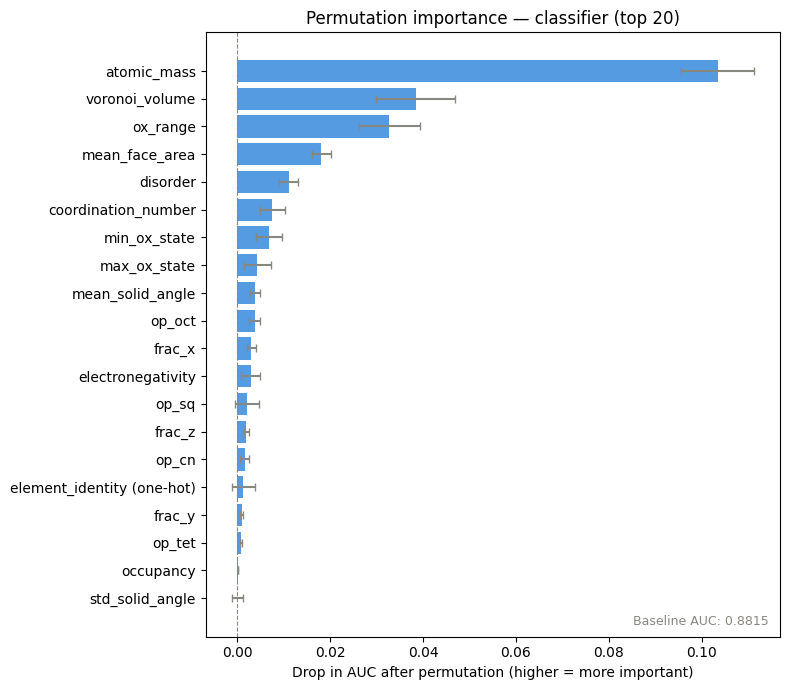


Top scalar features:
   1. atomic_mass                +0.1035 ± 0.0078
   2. voronoi_volume             +0.0384 ± 0.0086
   3. ox_range                   +0.0328 ± 0.0065
   4. mean_face_area             +0.0181 ± 0.0020
   5. disorder                   +0.0110 ± 0.0020
   6. coordination_number        +0.0076 ± 0.0027
   7. min_ox_state               +0.0069 ± 0.0028
   8. max_ox_state               +0.0043 ± 0.0030
   9. mean_solid_angle           +0.0038 ± 0.0011
  10. op_oct                     +0.0037 ± 0.0011


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# ── Feature names (117 total) ─────────────────────────────────────────────────
ELEMENT_SYMBOLS = [Element.from_Z(z).symbol for z in range(1, MAX_Z + 1)]
# 94 one-hot features

SCALAR_FEATURES = [
    'atomic_mass', 'atomic_radius', 'ionic_radius', 'electronegativity',
    'max_ox_state', 'min_ox_state', 'ox_state', 'ox_range',  # 8 scalar elemental
    'occupancy', 'disorder',                                  # 2 site
    'frac_x', 'frac_y', 'frac_z',                            # 3 fractional coords
    'coordination_number',                                    # 1
    'op_cn', 'op_tet', 'op_oct', 'op_sq', 'op_bent',         # 5 order params
    'voronoi_volume', 'mean_solid_angle', 'std_solid_angle', 'mean_face_area',  # 4 Voronoi
]  # 23 scalar features
SCALAR_FEATURES = [
    'atomic_mass', 'atomic_radius', 'ionic_radius', 'molar_volume',
    'electronegativity', 'max_ox_state', 'min_ox_state', 'ox_state', 'ox_range',
    'valence_electrons', 'd_electrons', 'is_d_block', 'is_f_block', 'mendeleev_no',
    'occupancy', 'disorder',
    'frac_x', 'frac_y', 'frac_z',
    'coordination_number',
    'op_cn', 'op_tet', 'op_oct', 'op_sq', 'op_bent',
    'voronoi_volume', 'mean_solid_angle', 'std_solid_angle', 'mean_face_area',
]  # 29 scalar features → total node features = 94 + 29 = 123

FEATURE_NAMES = ELEMENT_SYMBOLS + SCALAR_FEATURES  # 117 total

# ── Helper functions ──────────────────────────────────────────────────────────
def get_graph_feature_matrix(graphs):
    return np.array([g.x.numpy().mean(axis=0) for g in graphs])

def predict_from_features(feature_matrix, graphs, model, device, batch_size=64):
    preds = []
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feat_tensor = torch.tensor(feature_matrix, dtype=torch.float32)
    idx = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            bs = batch.num_graphs
            sizes    = batch.ptr[1:] - batch.ptr[:-1]
            expanded = torch.repeat_interleave(feat_tensor[idx:idx+bs].to(device), sizes, dim=0)
            batch.x  = expanded
            pred     = torch.sigmoid(model(batch))  # probabilities for classifier
            preds.extend(pred.cpu().numpy().flatten())
            idx += bs
    return np.array(preds)

# ── Permutation importance (AUC drop) ────────────────────────────────────────
def permutation_importance_auc(model, graphs, device, n_repeats=10, batch_size=64):
    model.eval()
    X = get_graph_feature_matrix(graphs)
    y = np.array([g.y.item() for g in graphs])

    baseline_auc = roc_auc_score(y, predict_from_features(X, graphs, model, device, batch_size))
    print(f"Baseline AUC: {baseline_auc:.4f}")

    n_features  = X.shape[1]
    importances = np.zeros((n_features, n_repeats))

    for f in range(n_features):
        for r in range(n_repeats):
            X_perm       = X.copy()
            X_perm[:, f] = np.random.permutation(X_perm[:, f])
            preds        = predict_from_features(X_perm, graphs, model, device, batch_size)
            importances[f, r] = baseline_auc - roc_auc_score(y, preds)
        print(f"  feature {f+1:03d}/{n_features} done", end="\r")

    print()
    return {"mean": importances.mean(axis=1), "std": importances.std(axis=1),
            "baseline_auc": baseline_auc, "raw": importances}

# ── Plot (top N, one-hot elements collapsed to a single bar) ──────────────────
def plot_importance(perm_result, feature_names=FEATURE_NAMES, top_n=20):
    means = perm_result["mean"]
    stds  = perm_result["std"]

    # Collapse all 94 one-hot element features into one representative score
    n_onehot = 94  # MAX_Z, hardcoded to match model

    onehot_importance = means[:n_onehot].mean()
    onehot_std        = means[:n_onehot].std()

    collapsed_names = np.array(["element_identity (one-hot)"] + SCALAR_FEATURES)
    collapsed_means = np.concatenate([[onehot_importance], means[n_onehot:]])
    collapsed_stds  = np.concatenate([[onehot_std],        stds[n_onehot:]])

    order  = np.argsort(collapsed_means)[-top_n:]
    names  = [collapsed_names[i] for i in order]
    m_vals = collapsed_means[order]
    s_vals = collapsed_stds[order]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(names, m_vals, xerr=s_vals, capsize=3, color="#378ADD", alpha=0.85, ecolor="#888780")
    ax.axvline(0, color="#888780", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Drop in AUC after permutation (higher = more important)")
    ax.set_title(f"Permutation importance — classifier (top {top_n})")
    ax.text(0.98, 0.02, f"Baseline AUC: {perm_result['baseline_auc']:.4f}",
            transform=ax.transAxes, ha="right", fontsize=9, color="#888780")
    plt.tight_layout()
    plt.savefig("permutation_importance_classifier.png", dpi=150)
    plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
perm_result = permutation_importance_auc(model, test_graphs, device, n_repeats=10)
plot_importance(perm_result)

# Numeric summary (scalar features only, sorted)
print("\nTop scalar features:")
scalar_means = perm_result["mean"][94:]
order = np.argsort(scalar_means)[::-1]
for rank, i in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {SCALAR_FEATURES[i]:<25s}  {scalar_means[i]:+.4f} ± {perm_result['std'][94+i]:.4f}")

In [ ]:
print(f"FEATURE_NAMES length: {len(FEATURE_NAMES)}")
print(f"ELEMENT_SYMBOLS length: {len(ELEMENT_SYMBOLS)}")
print(f"SCALAR_FEATURES length: {len(SCALAR_FEATURES)}")
print(f"perm_result mean length: {len(perm_result['mean'])}")
print(f"collapsed_names length: {len(['element_identity (one-hot)'] + list(FEATURE_NAMES[94:]))}")

FEATURE_NAMES length: 115
ELEMENT_SYMBOLS length: 92
SCALAR_FEATURES length: 23
perm_result mean length: 117
collapsed_names length: 22


Old for regression:

In [ ]:
# graphs = torch.load('crystal_graphs_v1.pt', weights_only=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CGCNN(
    node_features=24,
    edge_features=40,
    hidden_dim=64,
    num_conv_layers=3,
    dropout=0.1
).to(device)

import torch
from torch_geometric.loader import DataLoader

# ── 1. Load weights ───────────────────────────────────────────────────────────
model.load_state_dict(torch.load('cgcnn_model_v1.pt', map_location=device))
model.eval()  # disables dropout and batchnorm tracking

# ── 2. Predict a single graph ─────────────────────────────────────────────────
def predict_single(graph, model, device):
    graph = graph.to(device)
    with torch.no_grad():                    # disables gradient tracking (faster + less memory)
        pred = model(graph)
    return pred.item()

pred = predict_single(graphs[0], model, device)
print(f"Predicted: {pred:.4f}  |  True: {graphs[0].y.item():.4f}")

# ── 3. Predict a full dataset (batched) ───────────────────────────────────────
def predict_all(graphs, model, device, batch_size=64):
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)

    predictions, targets = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred  = model(batch)
            predictions.extend(pred.cpu().numpy().flatten())
            targets.extend(batch.y.cpu().numpy().flatten())

    return np.array(predictions), np.array(targets)

preds, targets = predict_all(graphs, model, device)
# plt.scatter(np.exp(1.5*targets + 1.7), np.exp(1.5 * preds + 1.7), alpha=0.7)
# plt.plot([np.exp(1.5*targets.min() + 1.7), np.exp(1.5*targets.max() + 1.7)], [np.exp(1.5*targets.min() + 1.7), np.exp(1.5*targets.max() + 1.7)], 'r--')
# plt.xlabel("True (normalized log Tc)")
# plt.ylabel("Predicted (normalized log Tc)")
# #plt.xscale('log')
# #plt.yscale('log')

# # ── 4. Evaluate ───────────────────────────────────────────────────────────────
# from sklearn.metrics import mean_absolute_error, r2_score

# mae = mean_absolute_error(targets, preds)
# r2  = r2_score(targets, preds)
# print(f"MAE:  {mae:.4f}")
# print(f"R²:   {r2:.4f}")




# ── 5. Predict a new structure (no known target) ──────────────────────────────
def predict_structure(cif_path, model, device, target=0.0):
    structure = Structure.from_file(cif_path)
    graph     = structure_to_graph(structure, target=target)   # target is a placeholder
    graph     = graph.to(device)
    with torch.no_grad():
        pred = model(graph)
    return pred.item()

#pred = predict_structure('my_new_crystal.cif', model, device)
#print(f"Predicted property: {pred:.4f}")

In [ ]:
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

# ── Feature names (update if you changed get_atom_features) ──────────────────
FEATURE_NAMES = [
    # Elemental
    "atomic_number", "atomic_mass", "atomic_radius", "ionic_radius",
    "electronegativity", "max_ox_state", "min_ox_state", "ox_state", "ox_range",
    # Site
    "occupancy", "disorder",
    # Structural
    "frac_x", "frac_y", "frac_z",
    "coordination_number",
    "op_cn", "op_tet", "op_oct", "op_sq", "op_bent",
    "voronoi_volume", "mean_solid_angle", "std_solid_angle", "mean_face_area",
]

# ── Helper: predict from raw node feature matrix ──────────────────────────────
# Both SHAP and permutation importance work by perturbing node features,
# so we need a function that accepts a plain numpy array and returns predictions.
# We pool perturbed features back into the existing graph structure.

def predict_from_features(feature_matrix, graphs, model, device, batch_size=64):
    """
    feature_matrix : np.ndarray of shape (N_graphs, N_node_features)
                     Each row is the *mean* node feature vector for one graph
                     (we use graph-level mean pooling to get a fixed-size input
                     that SHAP and permutation importance can work with).
    Returns        : np.ndarray of shape (N_graphs,)
    """
    preds = []
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feat_tensor = torch.tensor(feature_matrix, dtype=torch.float32)

    idx = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            bs = batch.num_graphs

            # Replace each node's features with the perturbed graph-mean
            # by expanding the per-graph vector back to per-node
            sizes    = batch.ptr[1:] - batch.ptr[:-1]           # nodes per graph
            expanded = torch.repeat_interleave(
                feat_tensor[idx:idx+bs].to(device), sizes, dim=0
            )
            batch.x  = expanded
            pred     = model(batch)
            preds.extend(pred.cpu().numpy().flatten())
            idx += bs

    return np.array(preds)


def get_graph_feature_matrix(graphs):
    """Summarise each graph as its mean node feature vector."""
    return np.array([g.x.numpy().mean(axis=0) for g in graphs])


# ══════════════════════════════════════════════════════════════════════════════
# 1. PERMUTATION IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════

def permutation_importance(model, graphs, device, n_repeats=10, batch_size=64):
    """
    For each feature:
      1. Record baseline MAE
      2. Shuffle that feature across all graphs n_repeats times
      3. Importance = mean increase in MAE after shuffling

    A large increase means the model relied heavily on that feature.
    """
    model.eval()
    X        = get_graph_feature_matrix(graphs)
    y        = np.array([g.y.item() for g in graphs])
    baseline = np.mean(np.abs(predict_from_features(X, graphs, model, device, batch_size) - y))

    n_features   = X.shape[1]
    importances  = np.zeros((n_features, n_repeats))

    for f in range(n_features):
        for r in range(n_repeats):
            X_permuted      = X.copy()
            X_permuted[:, f] = np.random.permutation(X_permuted[:, f])
            preds            = predict_from_features(X_permuted, graphs, model, device, batch_size)
            importances[f, r] = np.mean(np.abs(preds - y)) - baseline

        print(f"  feature {f+1:02d}/{n_features} done", end="\r")

    print()
    return {
        "mean":     importances.mean(axis=1),
        "std":      importances.std(axis=1),
        "baseline": baseline,
        "raw":      importances,
    }


# ══════════════════════════════════════════════════════════════════════════════
# 2. SHAP VALUES
# ══════════════════════════════════════════════════════════════════════════════

def compute_shap(model, graphs, device, n_background=50, n_explain=100, batch_size=64):
    """
    Uses KernelSHAP, which is model-agnostic and works with any GNN.

    n_background : number of graphs used as the SHAP background (reference) set
    n_explain    : number of graphs to explain (more = slower but stabler values)
    """
    model.eval()
    X = get_graph_feature_matrix(graphs)

    # Wrapper so SHAP can call the model like a plain function
    def model_predict(feature_matrix):
        return predict_from_features(feature_matrix, graphs[:len(feature_matrix)],
                                     model, device, batch_size)

    background = X[:n_background]
    explain    = X[:n_explain]

    explainer   = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(explain, nsamples=100, silent=True)

    return shap_values, explain


# ══════════════════════════════════════════════════════════════════════════════
# 3. PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

def plot_permutation_importance(perm_result, feature_names=FEATURE_NAMES, top_n=15):
    means = perm_result["mean"]
    stds  = perm_result["std"]

    # Sort by importance
    order   = np.argsort(means)[-top_n:]
    names   = [feature_names[i] for i in order]
    m_vals  = means[order]
    s_vals  = stds[order]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(names, m_vals, xerr=s_vals, capsize=3,
                   color="#378ADD", alpha=0.85, ecolor="#888780")
    ax.axvline(0, color="#888780", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Mean increase in MAE after permutation")
    ax.set_title(f"Permutation importance (top {top_n})")
    ax.text(0.98, 0.02, f"Baseline MAE: {perm_result['baseline']:.4f}",
            transform=ax.transAxes, ha="right", fontsize=9, color="#888780")
    plt.tight_layout()
    plt.savefig("permutation_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 4. RUN EVERYTHING
# ══════════════════════════════════════════════════════════════════════════════

model.eval()

print("Running permutation importance...")
perm_result = permutation_importance(model, graphs, device, n_repeats=10)
plot_permutation_importance(perm_result)


# Numeric summary
print("\nTop 10 features by permutation importance:")
order = np.argsort(perm_result["mean"])[::-1]
for rank, i in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[i]:<25s}  {perm_result['mean'][i]:+.4f} ± {perm_result['std'][i]:.4f}")


In [ ]:
import os

os.chdir("/content/ML_Personal_git")  # move into repo FIRST
token = "MY_TOKEN"


!git remote set-url origin https://{token}@github.com/SSBNS/ML_Personal_git.git

In [ ]:
!git status

In [ ]:
# import os
# os.chdir("/content/ML_Personal_git")  # make sure you're in the repo folder
!git add .
# !git add "3DSC_looker.ipynb"

In [ ]:
!git commit -m "Add results from Colab"
!git push

In [ ]:
!git reset HEAD^
!git push

Everything up-to-date


In [ ]:
!Add-Content .gitignore "classifier_crystal_graphs_v2.pt"
!git add .gitignore
!git commit -m "Ignore large model files"
!git push

/bin/bash: line 1: Add-Content: command not found
fatal: pathspec '.gitignore' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	classifier_crystal_graphs_v2.pt

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/ML_models/classifier_crystal_graphs_v2.pt'